In [88]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

In [89]:
df = pd.read_csv("Leigh1968_harelynx.csv")

h = df['hare'].values
l = df['lynx'].values
x_values = np.arange(len(h))
data = np.vstack([
    np.column_stack((np.full_like(x_values, 1), x_values, h)),
    np.column_stack((np.full_like(x_values, 2), x_values, l))
])

In [90]:
group_1 = data[data[:, 0] == 1]
group_2 = data[data[:, 0] == 2]

In [91]:
scale_factor = np.max([np.max(h), np.max(l)])
h_normalized = h / scale_factor
l_normalized = l / scale_factor

x_values = np.arange(len(h))

data = np.vstack([
    np.column_stack((np.full_like(x_values, 1), x_values, h_normalized)),
    np.column_stack((np.full_like(x_values, 2), x_values, l_normalized))
])

t_data = x_values
hare_data = h_normalized
lynx_data = l_normalized

Scale factor: 153000
Normalized hare range: 0.013 - 1.000
Normalized lynx range: 0.026 - 0.523


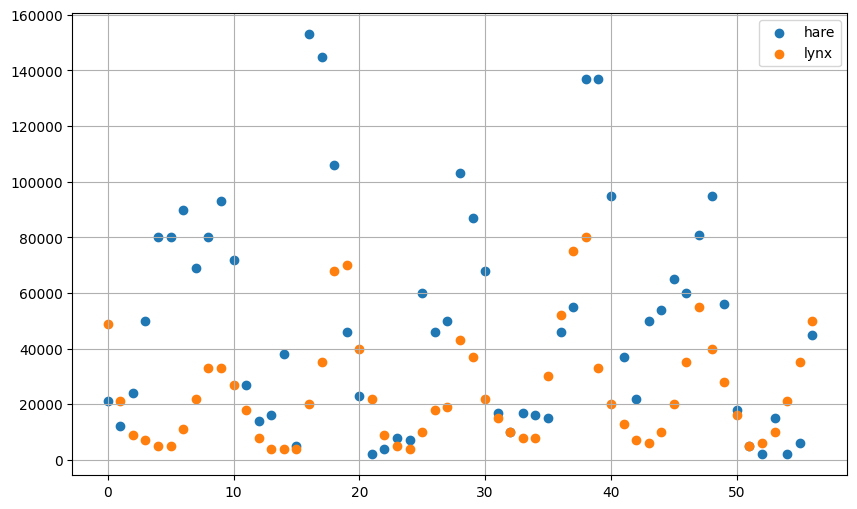

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(group_1[:, 1], group_1[:, 2], label='hare')
plt.scatter(group_2[:, 1], group_2[:, 2], label='lynx')
plt.legend()
plt.grid(True)

In [93]:
from scipy.integrate import odeint

In [94]:
def lotka_volterra(state, t, alpha, beta, gamma, delta):
    prey, predator = state
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = -gamma * predator + delta * prey * predator
    return [dprey_dt, dpredator_dt]

def solve_lotka_volterra(params, t, initial_conditions):
    alpha, beta, gamma, delta = params
    return odeint(lotka_volterra, initial_conditions, t, args=(alpha, beta, gamma, delta))

In [149]:
from scipy.optimize import differential_evolution, curve_fit

In [153]:
def model_error(params, t, hare_data, lynx_data):
    """
    Weighted error - emphasize peaks and troughs.
    """
    alpha, beta, gamma, delta = params
    
    initial_conditions = [hare_data[0], lynx_data[0]]
    
    solution = solve_lotka_volterra([alpha, beta, gamma, delta], t, initial_conditions)
    hare_model, lynx_model = solution[:, 0], solution[:, 1]
    
    hare_weight = 1.0 + 2.0 * np.abs(hare_data - np.mean(hare_data)) / np.std(hare_data)
    lynx_weight = 1.0 + 2.0 * np.abs(lynx_data - np.mean(lynx_data)) / np.std(lynx_data)
    
    hare_error = np.sum(hare_weight * (hare_model - hare_data)**2)
    lynx_error = np.sum(lynx_weight * (lynx_model - lynx_data)**2)
    
    return hare_error + lynx_error

def fit_lotka_volterra(t, hare_data, lynx_data):
    bounds = [(0.1, 3.0), (0.1, 2.0), (0.1, 3.0), (0.1, 3.0)]
    result = differential_evolution(
        model_error,
        bounds,
        args=(t, hare_data, lynx_data),
        strategy='best1bin',
        maxiter=100,
        popsize=15,
        tol=1e-7,
        mutation=(0.5, 1.5),
        recombination=0.7,
        seed=42,
        disp=True
    )
    
    return result.x, result.fun

In [154]:
best_params, error = fit_lotka_volterra(t_data, hare_data, lynx_data)
alpha, beta, gamma, delta = best_params

print(f"alpha prey growth rate: {alpha:.4f}")
print(f"beta predation rate: {beta:.4f}")
print(f"gamma predator death rate: {gamma:.4f}")
print(f"delta pr growth efficiency: {delta:.4f}")
print(f"error: {error:.2f}")

differential_evolution step 1: f(x)= 26.093528765437327
differential_evolution step 2: f(x)= 25.350394505336375


C:\Users\dana\AppData\Local\Temp\ipykernel_5208\279340117.py:30: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(lotka_volterra, initial_conditions, t, args=(alpha, beta, gamma, delta))


differential_evolution step 3: f(x)= 22.248662246535194
differential_evolution step 4: f(x)= 22.248662246535194
differential_evolution step 5: f(x)= 22.248662246535194
differential_evolution step 6: f(x)= 22.248662246535194
differential_evolution step 7: f(x)= 19.202986158983446
differential_evolution step 8: f(x)= 19.202986158983446
differential_evolution step 9: f(x)= 19.202986158983446
differential_evolution step 10: f(x)= 19.202986158983446
differential_evolution step 11: f(x)= 18.71869560243988
differential_evolution step 12: f(x)= 18.71869560243988
differential_evolution step 13: f(x)= 18.71869560243988
differential_evolution step 14: f(x)= 15.425694036800689
differential_evolution step 15: f(x)= 15.425694036800689
differential_evolution step 16: f(x)= 15.425694036800689
differential_evolution step 17: f(x)= 14.32879665137925
differential_evolution step 18: f(x)= 14.32879665137925
differential_evolution step 19: f(x)= 14.32879665137925
differential_evolution step 20: f(x)= 14.328

In [152]:
initial_conditions = [hare_data[0], lynx_data[0]]
solution = solve_lotka_volterra(best_params, t_data, initial_conditions)
hare_model, lynx_model = solution[:, 0], solution[:, 1]

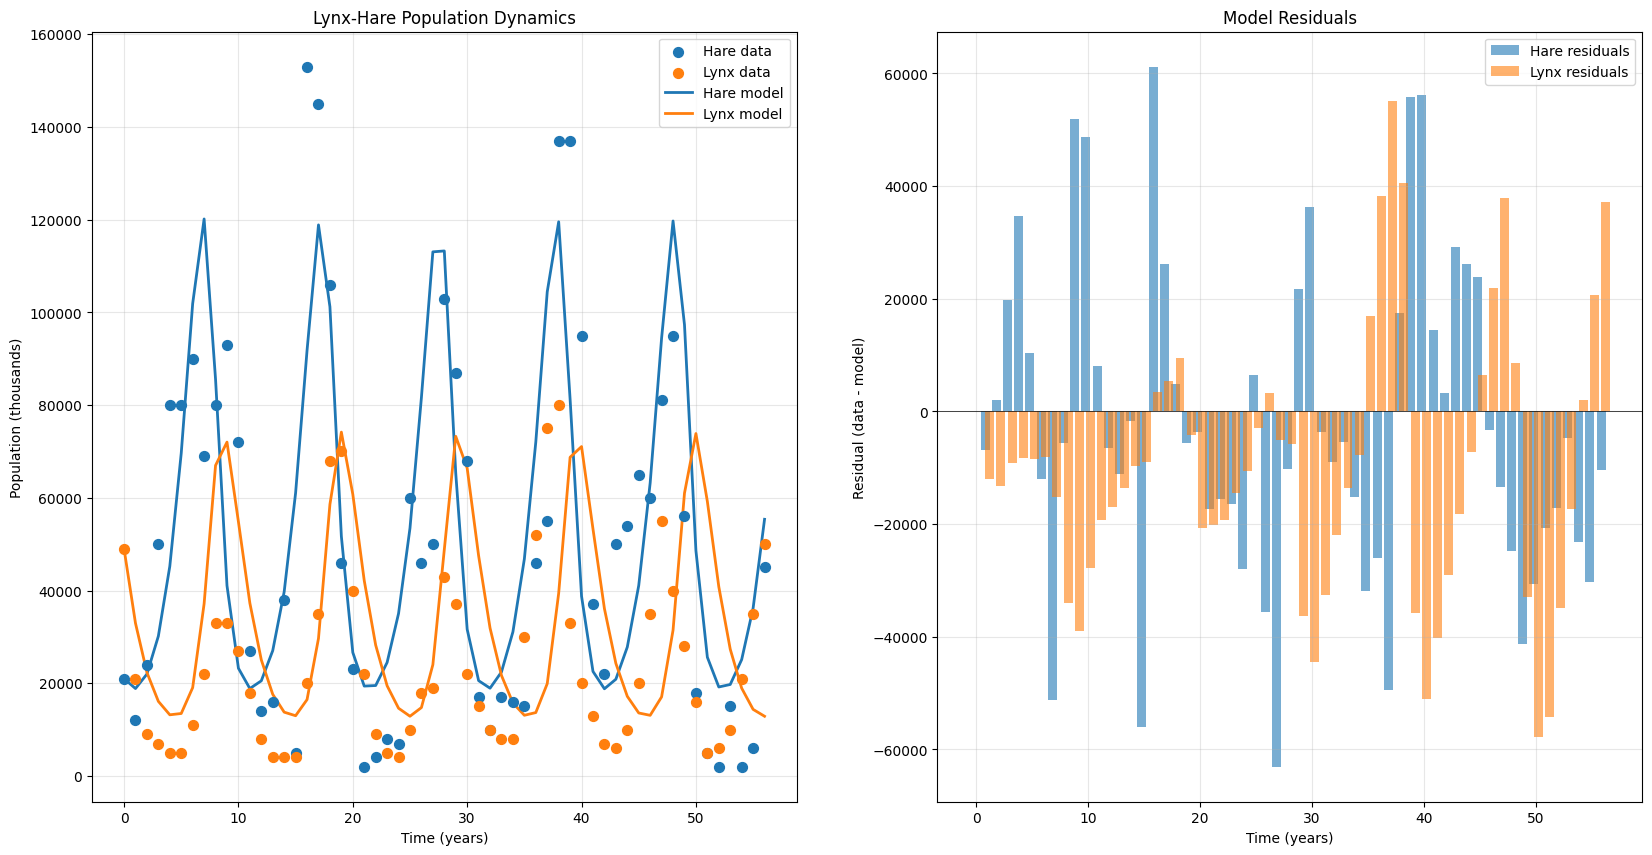

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))


ax = axes[0]
ax.scatter(t_data, hare_data * scale_factor, s=50, label='Hare data', zorder=5)
ax.scatter(t_data, lynx_data * scale_factor, s=50, label='Lynx data', zorder=5)
ax.plot(range(len(hare_model)), hare_model * scale_factor, linewidth=2, label='Hare model')
ax.plot(range(len(hare_model)), lynx_model * scale_factor, linewidth=2, label='Lynx model')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Population (thousands)')
ax.set_title('Lynx-Hare Population Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
hare_residuals = hare_data - hare_model
lynx_residuals = lynx_data - lynx_model
ax.bar(t_data - 0.2, hare_residuals * scale_factor, alpha=0.6, label='Hare residuals')
ax.bar(t_data + 0.2, lynx_residuals * scale_factor, alpha=0.6, label='Lynx residuals')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Residual (data - model)')
ax.set_title('Model Residuals')
ax.legend()
ax.grid(True, alpha=0.3)
